In [1]:
from google.colab import files
uploaded = files.upload()

Saving master_dataset.xslx.xlsx to master_dataset.xslx.xlsx


Dataset Shape: (27804, 55)

Columns:
 Index(['city', 'date', 'aqi', 'pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3',
       'source', 'objectid', 'oceans', 'regions', 'subregions',
       'sampling_method', 'measurement', 'unit', 'density_range',
       'density_class', 'short_reference', 'long_reference', 'doi',
       'organization', 'keywords', 'accession_number', 'accession_link',
       'latitude', 'longitude', 'globalid', 'x', 'y', 'case_id',
       'date_reported', 'region', 'country', 'pollutant_type',
       'pollutant_concentration_mg_kg', 'soil_ph', 'temperature_c',
       'humidity_%', 'rainfall_mm', 'crop_type', 'farming_practice',
       'nearby_industry', 'water_source_type', 'soil_texture',
       'soil_organic_matter_%', 'disease_type', 'disease_severity',
       'health_symptoms', 'age_group_affected', 'gender_most_affected',
       'mitigation_measure', 'case_resolved', 'follow_up_required'],
      dtype='object')

Features used: ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']

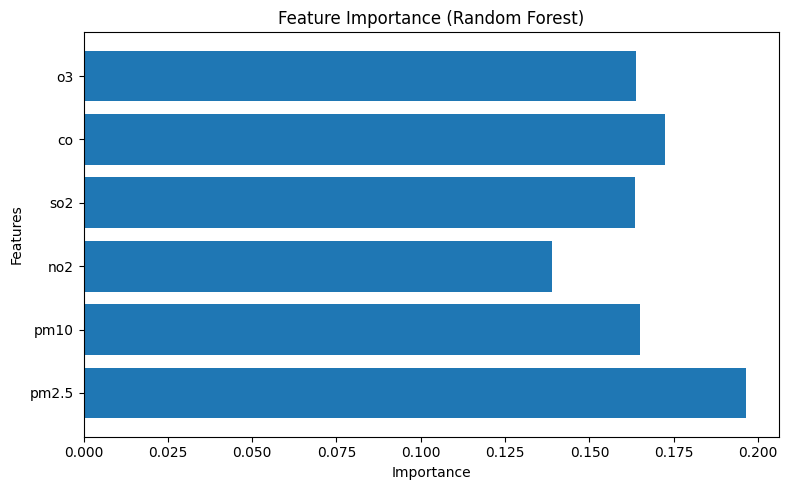

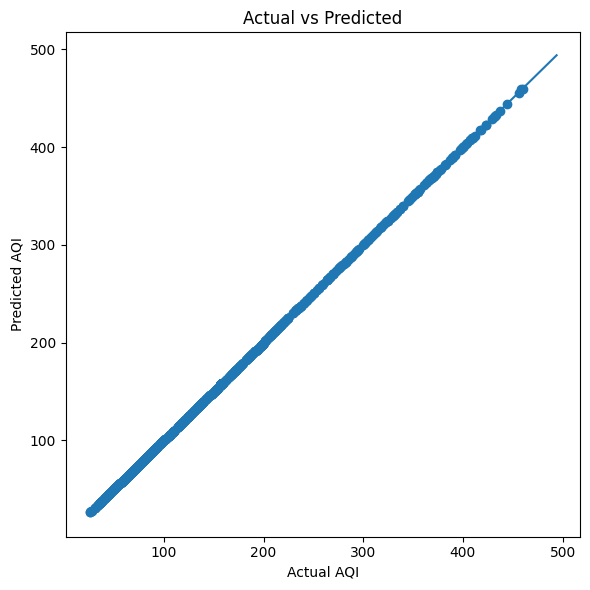

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_excel("master_dataset.xslx.xlsx")

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.columns = df.columns.str.strip()
df = df.select_dtypes(include=[np.number])

df = df.fillna(df.mean())

target_col = 'aqi'

if target_col not in df.columns:
    raise ValueError(f"{target_col} column not found in dataset")

features = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3']

features = [col for col in features if col in df.columns]

X = df[features]
y = df[target_col]

print("\nFeatures used:", features)

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining size:", X_train.shape)
print("Testing size :", X_test.shape)

# -----------------------------
# Train Model (Random Forest)
# -----------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# "Accuracy Report" (Regression Metrics)
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score (Accuracy):", r2)

importance = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted")

plt.plot([y.min(), y.max()], [y.min(), y.max()])

plt.tight_layout()
plt.show()